# Verify method with year 2000

Compare VizHub data for 7 PM2.5-related mortality outcomes in the year 2000 to those calculated using this worklow

In [1]:
import os
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from utils.mortality_utils import mortality
import config
from utils.utils import require_dir, create_global_country_map
import pathlib
from utils.utils import land_filter, autosize_figure, standardise_latlon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec

In [2]:
# === Path config ===
BMR_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "BMR")
POP_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "WorldPop")
MASK_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "BMR" / "masks" / "country")
PM_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "PM2.5_obs" / "IHME")
TMREL_DIR = require_dir(pathlib.Path(config.SCRATCH_ROOT) / "TMREL")
BMR_SCRATCH_DIR = require_dir(pathlib.Path(config.SCRATCH_ROOT) / "BMR")
SAVE_DIR = require_dir(pathlib.Path(config.PLOTTING_ROOT) / "example_workflow")

In [3]:
# For file names
GBD_version = "GBD23"

In [4]:
# === Load data ===
pop_file = "worldpop_2000_coarse_grid.nc"
pop_path = os.path.join(POP_DIR, pop_file)
population = xr.open_dataset(pop_path)
pop_2000 = population["population"]

pm_file = "IHME_GBD_2023_PM25_timeseries.nc"
pm_path = os.path.join(PM_DIR, pm_file)
pm = xr.open_dataset(pm_path)["pm25"]
# Calculate average across the "baseline" period
pm_2000 = pm.sel(time="2000").mean("time")
pm_2000 = standardise_latlon(pm_2000)
pm_2000 = pm_2000.sortby("lat")

in_file = "GBD_Country_Masks_0.10.nc"
in_path = os.path.join(MASK_DIR, in_file)
country_mask = xr.open_dataarray(in_path)

In [5]:
# === Health variables ===
# COPD, DIABETES, ISCHEMIC_HEART_DISEASE, LOWER_RESPIRATORY_INFECTIONS,
# LUNG_CANCER, STROKE, DEMENTIA
health_vars = ["COPD", "DIABETES", "ISCHEMIC_HEART_DISEASE",
               "LOWER_RESPIRATORY_INFECTIONS", "LUNG_CANCER",
               "STROKE", "DEMENTIA"]

## Gridpoint and country level mortality

In [6]:
RR_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / GBD_version / "RR_curves")

# TMREL from GBD 2021
TMREL = 4.15  # central estimate [95% Uniform CI 2.4 – 5.9]

cause = []
M_test = []
for health_VAR in health_vars:
    print(f"Processing mortality outcome {health_VAR}")
    pattern = os.path.join(RR_DIR, f"IHME_GBD_20{GBD_version[-2:]}_AIR_POLLUTION_*_PM_RR_{health_VAR}.nc")
    matches = glob.glob(pattern)
    if len(matches) == 0:
        raise FileNotFoundError(f"No .nc file found for variable: {health_VAR}")
    if len(matches) > 1:
        raise ValueError(f"Multiple .nc files matched for variable {health_VAR}: {matches}")
    RR_values = xr.open_dataset(matches[0])["mean"]

    # --- Scale the RR to the TMREL so that RR below the TMREL=1 ---
    # Updated GBD23 risk curves are log(RR), non updated curves are RR
    if RR_values[0] == 1:
        print("Data starts at 1 so they are 'Relative Risk'")
        # Calculate log(RR)
        logRR = np.log(RR_values)
        if np.any(logRR < 0) is True:
            raise ValueError("Values of logRR < 0, should start at 0")
        # Find the log(RR) at the TMREL
        logRR_tmrel = logRR.sel(exposure=TMREL, method="nearest")
    elif RR_values[0] == 0:
        print("Data starts at 0 so they are 'log(Relative Risk)'")
        # Data is already in logRR format
        logRR = RR_values
        if np.any(logRR < 0) is True:
            raise ValueError("Values of logRR < 0, should start at 0")
        # Find the log(RR) at the TMREL
        logRR_tmrel = logRR.sel(exposure=TMREL, method="nearest")
    else:
        raise ValueError(f"Data has unknown start value: {RR_values[0]}")

    # Shift the function by the log(RR) at the TMREL (logRR_tmrel) so that log(RR)=0 at TMREL
    logRR_shifted = logRR - logRR_tmrel

    # Set log(RR) below TMREL as 0 and exponentiate to get RR
    scaled_RR = np.exp(logRR_shifted.where(logRR_shifted["exposure"] >= TMREL, 0))

    bmr_file = f"{GBD_version}_BMR_Global_Country_Map_{health_VAR}_2000.nc"
    bmr_path = os.path.join(BMR_DIR, bmr_file)
    BMR = xr.open_dataarray(bmr_path)  # central estimate

    # Adjust indices to match (with small tolerance)
    # e.g., max 1e-7 km distance
    pm_2000 = pm_2000.reindex_like(BMR, method="nearest", tolerance=1e-2,
                               fill_value=0)
    pop_2000 = pop_2000.reindex_like(BMR, method="nearest", tolerance=1e-2)

    # Find RR at each grid point
    RR = scaled_RR.interp(exposure=pm_2000)
    # Calculate the attributable fraction
    AF = 1 - (1/RR)

    M = mortality(AF, BMR, pop_2000)

    M_test.append(M.sum(dim=("lat", "lon")))

    countries = []
    # Loop over countries and sum the mortality for each country
    for i in range(len(country_mask.country)):
        mask = country_mask.isel(country=i)
        # Sum mortality of country (based on central estimates)
        M_country = (xr.where(
            mask == 1,
            M,
            np.nan
        )).sum(dim=("lat", "lon"))
        countries.append(M_country.drop_vars("country", errors='ignore'))

    del M

    mortality_country = xr.concat(countries,
                                  dim=xr.DataArray(country_mask["country"],
                                                   dims="country",
                                                   name="country"))
    cause.append(mortality_country)

cause_mortality = xr.concat(cause,
                              dim=xr.DataArray(health_vars,
                                               dims="cause",
                                               name="cause"))
total_mortality = cause_mortality.sum("cause")

Processing mortality outcome COPD
Data starts at 1 so they are 'Relative Risk'
Processing mortality outcome DIABETES
Data starts at 1 so they are 'Relative Risk'
Processing mortality outcome ISCHEMIC_HEART_DISEASE
Data starts at 0 so they are 'log(Relative Risk)'
Processing mortality outcome LOWER_RESPIRATORY_INFECTIONS
Data starts at 0 so they are 'log(Relative Risk)'
Processing mortality outcome LUNG_CANCER
Data starts at 1 so they are 'Relative Risk'
Processing mortality outcome STROKE
Data starts at 0 so they are 'log(Relative Risk)'
Processing mortality outcome DEMENTIA
Data starts at 0 so they are 'log(Relative Risk)'


Plot for comparison

In [7]:
plot_workflow = land_filter(create_global_country_map(total_mortality, MASK_DIR))

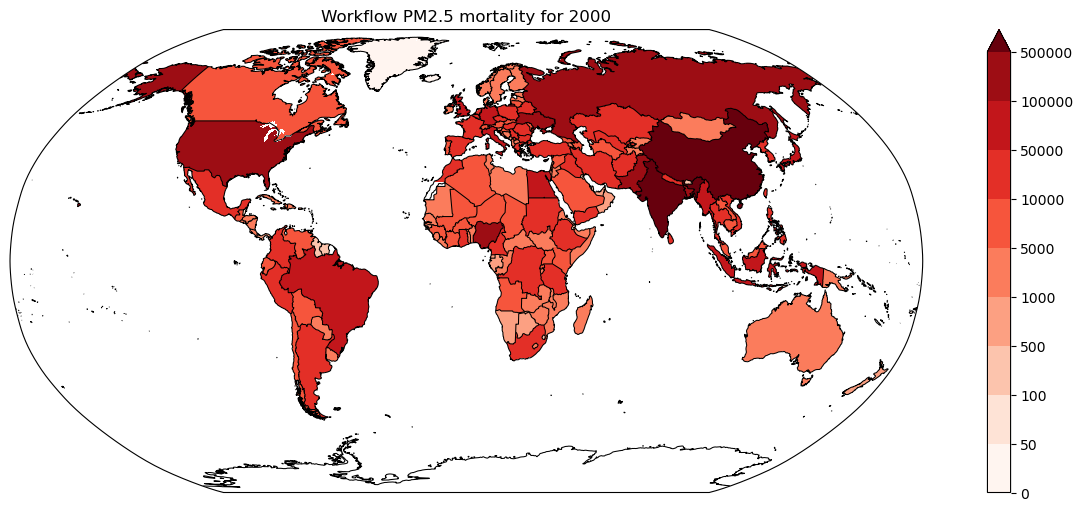

In [8]:
fig = plt.figure(figsize=autosize_figure(1, 1, xscale_factor=2))
gs = GridSpec(1, 1)  # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

col_map = plt.get_cmap('Reds')

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')


# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
plot_workflow.plot(transform=ccrs.PlateCarree(), cmap=col_map, levels=[0, 50, 100, 500, 1000, 5000, 10000, 50000, 100000, 500000])
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("Workflow PM2.5 mortality for 2000")

out_file = "Workflow_pm25_mortality_2000.png"
out_path = os.path.join(SAVE_DIR, out_file)
plt.savefig(out_path, dpi=300)

## Global mortality

In [9]:
# === Calculate the scalar distributions ===
n_samples = 300

RR_DIR = require_dir(pathlib.Path(config.SCRATCH_ROOT) / "rr_pm25")

cause = []
for health_VAR in health_vars:
    print(f"Processing health variable {health_VAR}")

    # RR from GBD23 (normal distribution)
    rr_file = f"{GBD_version}_RR_{health_VAR}_{n_samples}_samples_pm25.nc"
    rr_path = os.path.join(RR_DIR, rr_file)
    rr_da = xr.open_dataarray(rr_path)

    del rr_file, rr_path

    # Load BMR for each grid point (normal distribution)
    bmr_file = f"{GBD_version}_BMR_Country_Mask_{health_VAR}_{n_samples}_samples_2000.nc"
    bmr_path = os.path.join(BMR_SCRATCH_DIR, bmr_file)
    BMR = xr.open_dataarray(bmr_path)
    BMR = BMR.drop_vars("region")

    del bmr_file, bmr_path

    pm_2000 = pm_2000.reindex_like(BMR, method="nearest", tolerance=1e-2,
                               fill_value=0)
    pop_2000 = pop_2000.reindex_like(BMR, method="nearest", tolerance=1e-2)

    # Find the RR at each grid point
    RR = rr_da.interp(exposure=pm_2000)
    RR = RR.drop_vars(["exposure"])

    del rr_da

    # Calculate the attributable fraction
    AF = (1 - (1/RR))

    del RR

    # Calculate mortality at each grid point for n samples
    M = mortality(AF, BMR, pop_2000)

    del AF, BMR

    # Calculate the total global mortality
    global_M = M.sum(dim=("lat", "lon"))

    del M

    cause.append(global_M)

cause_mortality = xr.concat(cause,
                              dim=xr.DataArray(health_vars,
                                               dims="cause",
                                               name="cause"))
total_mortality = cause_mortality.sum("cause")

Processing health variable COPD
Processing health variable DIABETES
Processing health variable ISCHEMIC_HEART_DISEASE
Processing health variable LOWER_RESPIRATORY_INFECTIONS
Processing health variable LUNG_CANCER
Processing health variable STROKE
Processing health variable DEMENTIA


In [10]:
mean = total_mortality.mean("samples").values.round(-3)
lower = total_mortality.quantile(0.025, "samples").values.round(-3)
upper = total_mortality.quantile(0.975, "samples").values.round(-3)
print(f"Global mortality is {mean} [95% CI: {lower} - {upper}]")

Global mortality is 5063000.0 [95% CI: 4468000.0 - 5589000.0]


# Vizhub data

In [11]:
GBD_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "GBD23")
gbd_2010_file = "IHME-GBD_2023_DATA-pm25_mortality_2000_newlabels.nc"
path = os.path.join(GBD_DIR, gbd_2010_file)
gbd_2000 = xr.open_dataset(path)
total_gbd_2000 = gbd_2000.sum("cause")

gbd_mean = total_gbd_2000["val"]
plot_gbd = land_filter(create_global_country_map(gbd_mean, MASK_DIR))

Plot for comparison

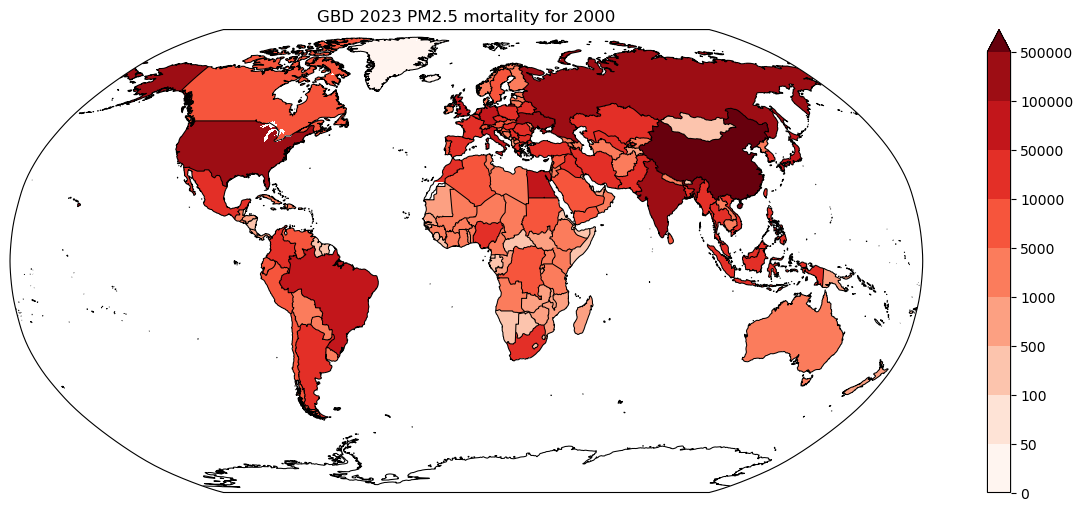

In [12]:
fig = plt.figure(figsize=autosize_figure(1, 1, xscale_factor=2))
gs = GridSpec(1, 1)  # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

col_map = plt.get_cmap('Reds')

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')


# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
plot_gbd.plot(transform=ccrs.PlateCarree(), cmap=col_map, levels=[0, 50, 100, 500, 1000, 5000, 10000, 50000, 100000, 500000])
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("GBD 2023 PM2.5 mortality for 2000")

out_file = "GBD23_pm25_mortality_2000.png"
out_path = os.path.join(SAVE_DIR, out_file)
plt.savefig(out_path, dpi=300)

## Global mortality - vizhub

In [13]:
gbd_mean = total_gbd_2000.sel(country="Global")["val"].values.round(-3)
gbd_upper = total_gbd_2000.sel(country="Global")["upper"].values.round(-3)
gbd_lower = total_gbd_2000.sel(country="Global")["lower"].values.round(-3)
print(f"Global mortality is {gbd_mean} [95% CI: {gbd_lower} - {gbd_upper}]")

Global mortality is 2847000.0 [95% CI: 1752000.0 - 4122000.0]
